In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [6]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)
graph_builder

In [7]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [8]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm=ChatGroq(model="openai/gpt-oss-20b") 

In [9]:
llm=init_chat_model("groq:openai/gpt-oss-20b")

In [10]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [11]:
graph_builder=StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot", END)

graph=graph_builder.compile()

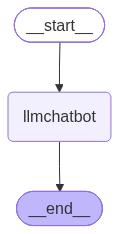

In [12]:
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [13]:
response = graph.invoke({"messages":"What is the Capital Of China"})

In [14]:
response["messages"][-1].content

'The capital of China is **Beijing**.'

In [15]:
for event in graph.stream({"messages":"Hi, How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)


Hello! I'm just a bunch of code, so I don't have feelings, but I'm here and ready to help. How can I assist you today?


In [16]:
from langchain_tavily import TavilySearch
tool=TavilySearch(max_results=2)
tool.invoke("What is Langgraph")

{'query': 'What is Langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [34]:
# Custom Functions
def multiply(a:int,b:int):
    """_Summery
    
    Args:
        a (int) : _description_
        b (int) : _description_

    Returns:
        int: output int

    """
    return a * b

In [35]:
tools=[tool,multiply]

In [36]:
llm_with_tool=llm.bind_tools(tools)

In [37]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F60D26C690>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F60D26D090>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and 

In [38]:
#State Graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Node Defnition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

# Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",tools_condition
)
builder.add_edge("tools",END)

# Compile

graph = builder.compile()


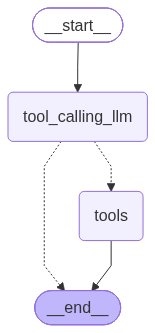

In [39]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [25]:
response = graph.invoke({"messages":"What is the Recent AI News"})

In [26]:
response

{'messages': [HumanMessage(content='What is the Recent AI News', additional_kwargs={}, response_metadata={}, id='7a2568c7-d4b6-4f7d-97b5-46cbbc5361c8'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks "What is the Recent AI News". We need to provide recent AI news. We should browse the web for up-to-date info. Use tavily_search. We\'ll search for recent AI news.', 'tool_calls': [{'id': 'fc_e02dd0ce-db96-4930-a2f7-07b6963c2766', 'function': {'arguments': '{"query":"recent AI news 2026 September","search_depth":"advanced"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 347, 'total_tokens': 427, 'completion_time': 0.080765826, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.018106163, 'prompt_tokens_details': None, 'queue_time': 0.264625114, 'total_time': 0.098871989}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_639a5351c8', 'service_tie

In [27]:
response['messages'][-1].content

'{"query": "recent AI news 2026 September", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.marketingprofs.com/opinions/2026/55792/ai-update-september-4-2026-ai-news-and-views-from-the-past-week", "title": "AI Update, September 4, 2026: AI News and Views From the Past ...", "content": "EU AI Act enters enforcement phase with transparency rules. The EU AI Act has entered a new enforcement phase, with transparency and disclosure requirements now applying to chatbots and AI-generated content. The EU AI Office can request information from covered companies and seek model access, although it has not yet pursued misconduct cases. Major AI providers are already adapting: Anthropic plans text watermarking and a detection API, Google and Meta are developing transparency tools, OpenAI is publishing training-data summaries and provenance signals, and Microsoft is changing internal governance and risk management. Additional rules for high-risk AI systems

In [28]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the Recent AI News
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_e02dd0ce-db96-4930-a2f7-07b6963c2766)
 Call ID: fc_e02dd0ce-db96-4930-a2f7-07b6963c2766
  Args:
    query: recent AI news 2026 September
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026 September", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.marketingprofs.com/opinions/2026/55792/ai-update-september-4-2026-ai-news-and-views-from-the-past-week", "title": "AI Update, September 4, 2026: AI News and Views From the Past ...", "content": "EU AI Act enters enforcement phase with transparency rules. The EU AI Act has entered a new enforcement phase, with transparency and disclosure requirements now applying to chatbots 

In [40]:
response=graph.invoke({"messages":"What is 2 multiple by 56"})

In [41]:
response

{'messages': [HumanMessage(content='What is 2 multiple by 56', additional_kwargs={}, response_metadata={}, id='9a68d31e-c391-4df0-8a36-27865d26b846'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is 2 multiple by 56". Likely they mean "2 multiplied by 56" which is 112. They might want the result. No need to use search. But we can use the multiply function.', 'tool_calls': [{'id': 'fc_b9a9dd48-8332-490c-9586-58967df662c9', 'function': {'arguments': '{"a":2,"b":56}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 349, 'total_tokens': 426, 'completion_time': 0.08396679, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.021009293, 'prompt_tokens_details': None, 'queue_time': 0.264735824, 'total_time': 0.104976083}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_851252edc2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logpro

In [43]:
response['messages'][-1].content

'112'

In [44]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiple by 56
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_b9a9dd48-8332-490c-9586-58967df662c9)
 Call ID: fc_b9a9dd48-8332-490c-9586-58967df662c9
  Args:
    a: 2
    b: 56
================================= Tool Message =================================
Name: multiply

112


In [45]:
response=graph.invoke({"messages":"What is 2 multiple by 56 and multiply by 100"})

In [46]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiple by 56 and multiply by 100
================================== Ai Message ==================================

2 × 56 = 112  
112 × 100 = 11 200  

So the result is **11 200**.


In [47]:
response=graph.invoke({"messages":"What is 2 multiple by 56 and multiply by 100 and provide me latest Telugu Movies"})

In [48]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiple by 56 and multiply by 100 and provide me latest Telugu Movies
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_234f00a0-7dd5-4fb2-b8c2-079747e38cde)
 Call ID: fc_234f00a0-7dd5-4fb2-b8c2-079747e38cde
  Args:
    query: latest Telugu movies 2026
    search_depth: advanced
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "latest Telugu movies 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://in.bookmyshow.com/explore/telugu-movies", "title": "Latest Telugu Movies 2026 | New Tollywood Movies Releases - BookMyShow", "content": "## Catch the latest Tollywood blockbusters\n\nFor those who love staying updated, check out the latest Tollywood movies currently showing in theaters near you, and don’t miss the 

In [49]:
# Reach Agent Architecture
#State Graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Node Defnition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

# Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",tools_condition
)
builder.add_edge("tools","tool_calling_llm")

# Compile

graph = builder.compile()

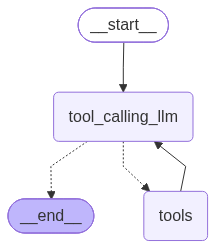

In [50]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [55]:
response=graph.invoke({"messages":"What is 2 multiple by 56 and provide me latest Telugu Movies in 2026 September"})

In [56]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiple by 56 and provide me latest Telugu Movies in 2026 September
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_97f5af7c-cc7a-4eaa-b47a-24c01b20539b)
 Call ID: fc_97f5af7c-cc7a-4eaa-b47a-24c01b20539b
  Args:
    query: September 2026 Telugu movies release
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "September 2026 Telugu movies release", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.myvi.in/blog/telugu-ott-releases-this-week", "title": "OTT Releases This Week Telugu (ఈ వారం తెలుగు OTT విడుదలలు) – 5th Sep to 11th Sep", "content": "|  |  |\n --- |\n| Release Date | September 4, 2026 |\n| Where to watch | Amazon Prime Video |\n| Language | Telugu |\n| Cast | Prakash Raj, Meka

In [57]:
response['messages'][-1].content

'**Answer**\n\n| # | Title | Release Date (Sept\u202f2026) | Platform / Release Type | Notes |\n|---|-------|--------------------------|------------------------|-------|\n| 1 | **EPIC – FIRST SEMESTER** | 11\u202fSept\u202f2026 | Theatrical (Cinemas) | Starring Anand Deverakonda & Vaishnavi Chaitanya, a romantic‑drama set in London. |\n| 2 | **Korean\u202fKanakaraju** | 4\u202fSept\u202f2026 | Netflix | Telugu‑dubbed film featuring Varun\u202fTej, Ritika\u202fNayak & Satya\u202fAkkala. |\n| 3 | **Unmadham** | 4\u202fSept\u202f2026 | SonyLIV | Telugu‑dubbed crime‑thriller starring Kunchacko\u202fBoban, Lijo\u202fMol\u202fJose & Sabumon\u202fAbdusamad. |\n| 4 | **G.D.N** | 4\u202fSept\u202f2026 | Amazon\u202fPrime Video | Telugu‑dubbed biopic about inventor G.\u202fD.\u202fNaidu. |\n| 5 | **Jagamae\u202fSangeetham** | 4\u202fSept\u202f2026 | (Streaming platform not specified) | Story about a music heir confronting family legacy. |\n| 6 | **Harsheni\u202fMani\u202fArasan** | 4\u202fSept\u

In [58]:
response['messages'][-2].content

'{"query": "September 2026 Telugu movies release", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.myvi.in/blog/telugu-ott-releases-this-week", "title": "OTT Releases This Week Telugu (ఈ వారం తెలుగు OTT విడుదలలు) – 5th Sep to 11th Sep", "content": "|  |  |\\n --- |\\n| Release Date | September 4, 2026 |\\n| Where to watch | Amazon Prime Video |\\n| Language | Telugu |\\n| Cast | Prakash Raj, Meka Srikanth |\\n| IMDb rating | NA |\\n\\n### G.D.N\\n\\nG.D.N is a biopic on inventor G. D. Naidu, tracing his remarkable journey as he overcomes numerous challenges and defies the restrictions of colonial rule. The film explores his determination, ingenuity, and contributions that helped establish him as one of India’s greatest innovators.\\n\\n|  |  |\\n --- |\\n| Release Date | September 4, 2026 |\\n| Where to watch | Netflix |\\n| Language | Tamil Dub |\\n| Cast | R. Madhavan, Sathyaraj, Jayaram |\\n| IMDb rating | 8.5 |\\n\\n### Korean Kanakaraju 

In [59]:
# Reach Agent Architecture
#State Graph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
# Node Defnition

memory = MemorySaver()

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

# Graph

builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

# Add Edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",tools_condition
)
builder.add_edge("tools","tool_calling_llm")

# Compile

graph = builder.compile(checkpointer=memory)

In [62]:
config = {"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"My Name is Sudheer Gundra"},config=config)
response['messages'][-1].content

'Nice to meet you, Sudheer Gundra! How can I help you today?'

In [68]:
response=graph.invoke({"messages":"What is My Name"},config=config)
response['messages'][-1].content

'Your name is **Sudheer\u202fGundra**.'

In [ ]:
config = {"configurable":{"thread_id":"2"}}

for chunk in graph.stream({'message':"Hi, My name is Sudheer and I like Cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='My Name is Sudheer Gundra', additional_kwargs={}, response_metadata={}, id='291912c6-8998-4b4f-a920-9d8353092eba'), AIMessage(content='Nice to meet you, Sudheer! How can I assist you today?', additional_kwargs={'reasoning_content': 'The user says: "My Name is Sudheer Gundra". They haven\'t asked a question. Likely they want to introduce themselves. We can respond politely acknowledging their name. Maybe ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 348, 'total_tokens': 415, 'completion_time': 0.068615624, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.018264164, 'prompt_tokens_details': None, 'queue_time': 0.262499529, 'total_time': 0.086879788}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_66f3850a1a', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07803-e619-7830-82bd-7dc9c458b93d-0', to

In [ ]:
for chunk in graph.stream({'message':"And also I like Football"},config,stream_mode="value"):
    print(chunk)

{'tool_calling_llm': {'messages': [AIMessage(content='Your name is **Sudheer\u202fGundra**.', additional_kwargs={'reasoning_content': 'User repeating "My Name is Sudheer Gundra". Then asks "What is My Name". The assistant answered. Now they might expect something else? The user might be testing the assistant. The last response is correct. Probably no further action needed.'}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 535, 'total_tokens': 607, 'completion_time': 0.074870594, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.030179866, 'prompt_tokens_details': None, 'queue_time': 0.261090978, 'total_time': 0.10505046}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4a35f7bd1b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07818-b179-7fb3-a401-6868983db33a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 535, 'output_tokens':